# Pseudomonas PINN

## 1. Configure Training


In [1]:
from src.utils import load_pseudomonas_splits
from src.utils.training import TrainingConfig, train_pinn
from src.models.pinn import PseudomonasBIOSODE

PROCESSED_CSV = "data/processed/ambr_preprocessed.csv"
RESULTS_DIR = "results"

SELECTED_EXPERIMENT_ID = "AMBR2_7"
NUM_EPOCHS = 50000

config = TrainingConfig(
    processed_csv=PROCESSED_CSV,
    results_dir=RESULTS_DIR,
    experiment_id=SELECTED_EXPERIMENT_ID,
    experiment_name=f"pseudomonas_pinn_{SELECTED_EXPERIMENT_ID}",
    seed=42,
    n_neurons=20,
    n_hidden_layers=7,
    num_epochs=NUM_EPOCHS,
    learning_rate=1e-4,
    data_loss_weight=1.0,
    residual_loss_weight=1.0,
    auxiliary_loss_weight=1.0,
    regularization_loss_weight=1.0,
    use_softadapt=True,
    obs_fit_weights=(1.0, 1.0, 1.0, 1.0),  # glucose, biomass, O2, pH
    aux_fit_weights=(1.0,) * len(PseudomonasBIOSODE.state_names),
    res_eq_weights=(1e-15,) * len(PseudomonasBIOSODE.state_names),
    reg_eq_weights=(1e-6,) * len(PseudomonasBIOSODE.state_names),
    test_fraction=0.2,
    split_strategy="random",
)

print("Selected experiment:", SELECTED_EXPERIMENT_ID)


Selected experiment: AMBR2_7


## 2. Run Training


In [2]:
train_dataset, test_dataset = load_pseudomonas_splits(
    PROCESSED_CSV,
    experiment_id=SELECTED_EXPERIMENT_ID,
    test_fraction=config.test_fraction,
    split_strategy=config.split_strategy,
    random_seed=config.seed,
)

result = train_pinn(config)
print("\nOutput dir:", result["output_dir"])
print("Final loss:", result["history"]["loss"][-1])
print("Learned params:", result["learned_params"])



Output dir: results/AMBR2_7
Final loss: 0.08454863727092743
Learned params: {'mu_max': 0.00010502299119252712, 'Ksubs': 0.4752720892429352, 'KLaO2': 1.9997073411941528, 'KLaCO2': 417.13958740234375}


## 3. Evaluate and Visualize


### 3.1 Loss, R2 Score

Track total, data, residual, auxiliary, regularization losses, and mean R2 score per epoch.


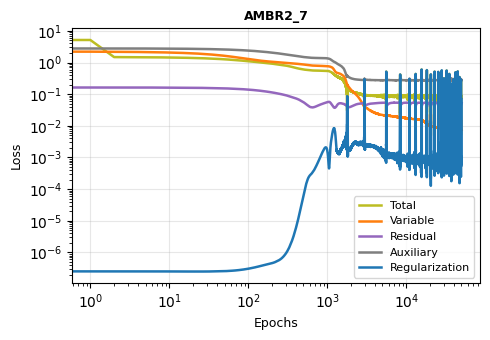

In [3]:
from src.utils.evaluation import plot_loss, plot_r2, plot_r2_by_target

plot_loss(result)


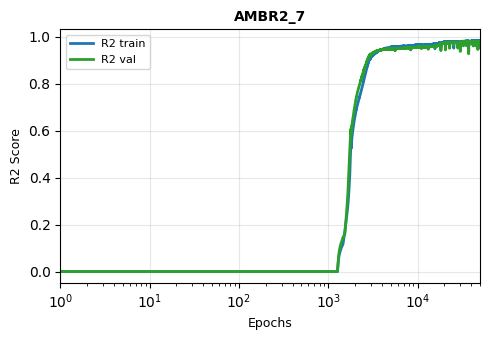

In [4]:
plot_r2(result)


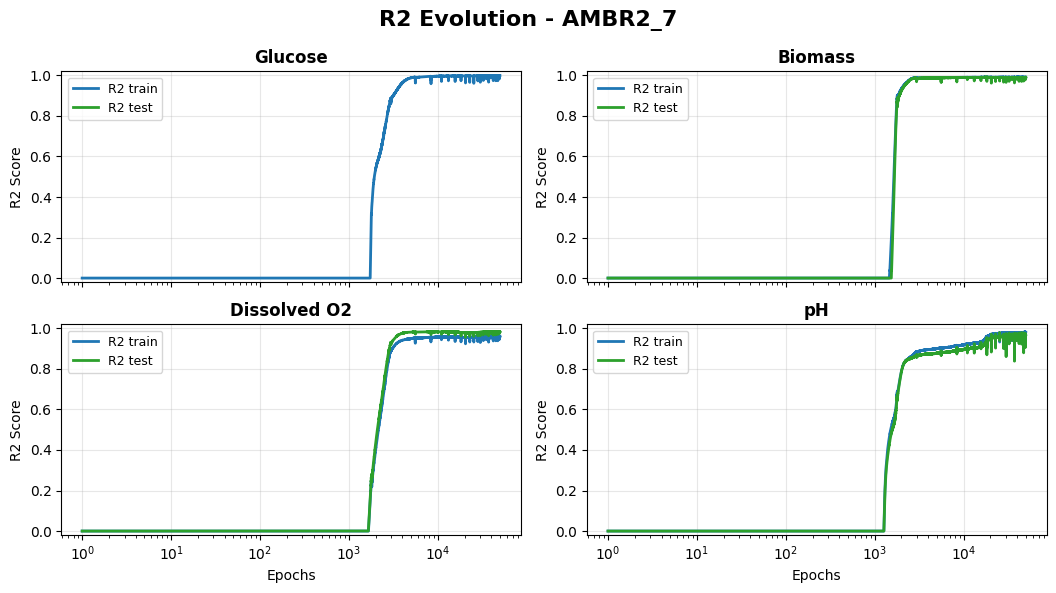

In [5]:
plot_r2_by_target(result)


### 3.2 PINN vs Data

Compare model predictions against measured observables for the selected experiment.


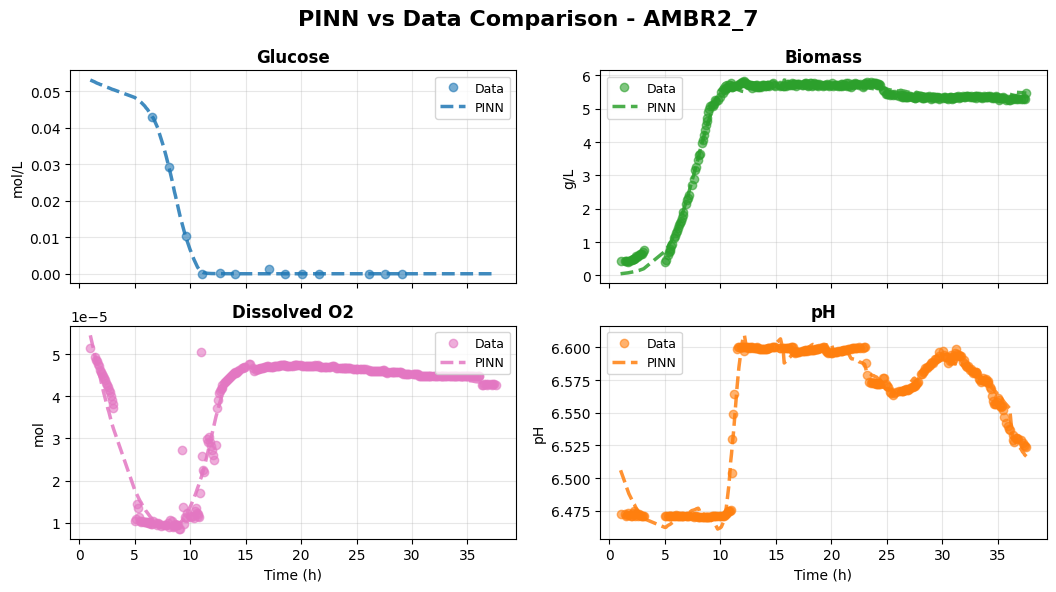

In [6]:
from src.utils.evaluation import plot_observable_predictions

plot_observable_predictions(
    result["model"],
    result["train_dataset"],
    experiment_id=SELECTED_EXPERIMENT_ID,
)


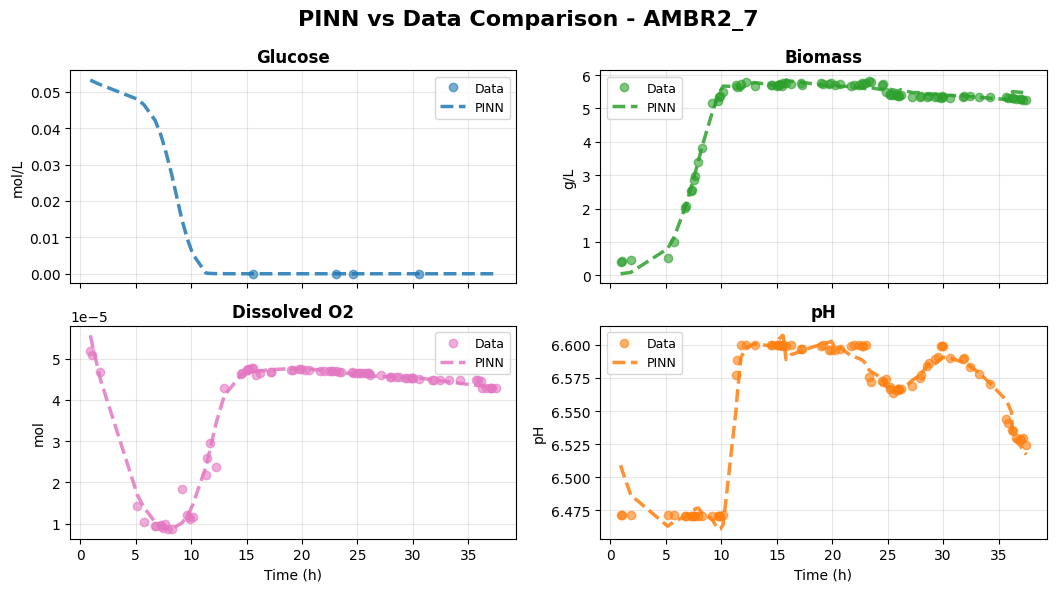

In [7]:
plot_observable_predictions(
    result["model"],
    result["test_dataset"],
    experiment_id=SELECTED_EXPERIMENT_ID,
)


### 3.3 Metrics

Compute train/test observable metrics and save reports.


In [8]:
from src.utils import evaluate_observables, parameter_report, save_reports

train_metrics = evaluate_observables(result["model"], result["train_dataset"])
test_metrics = evaluate_observables(result["model"], result["test_dataset"])
params = parameter_report(result)

print("Train metrics")
display(train_metrics)

print("Test metrics")
display(test_metrics)

print("Parameter report")
display(params)

report_paths = save_reports(result)
report_paths


Train metrics


,observable,n,rmse,mae,r2
0,glucose_mol_l,13,0.000354,0.000153,0.999284
1,biomass_g_l,332,0.149776,0.108263,0.991138
2,O2_l_mol,332,0.000003,0.000001,0.960677
3,pH,332,0.006964,0.004594,0.980913


Test metrics


,observable,n,rmse,mae,r2
0,glucose_mol_l,4,1.706216e-07,1.059161e-07,NaN
1,biomass_g_l,84,1.379046e-01,1.113317e-01,0.990200
2,O2_l_mol,84,1.781579e-06,8.756305e-07,0.983457
3,pH,84,9.291360e-03,6.242763e-03,0.964462


Parameter report


,parameter,default_value,learned_value,range_low,range_high,relative_change
0,mu_max,0.009,0.000105,9.000000e-06,9.0,-0.988331
1,Ksubs,0.005,0.475272,5.000000e-07,5.0,94.054418
2,KLaO2,2.000,1.999707,2.000000e-03,2000.0,-0.000146
3,KLaCO2,10.000,417.139587,1.000000e-02,10000.0,40.713959


{'metrics_train': PosixPath('results/AMBR2_7/metrics_train.csv'),
 'metrics_test': PosixPath('results/AMBR2_7/metrics_test.csv'),
 'parameters': PosixPath('results/AMBR2_7/parameter_report.csv')}